In [ ]:
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from google.colab import drive
drive.mount('/content/drive')

BASE   = Path('/content/drive/MyDrive/Diplom2')
META   = BASE / 'data' / 'meta'
FEAT   = BASE / 'data' / 'features'
MODELS = BASE / 'checkpoints' / 'classic'
MODELS.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(BASE / 'code'))

warnings.filterwarnings('ignore', category=UserWarning)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#*n_orig = np.load(BASE / 'data' / 'preprocessed' / 'signals_raw.npy', mmap_mode='r').shape[0]
#print('n_orig:', n_orig)

#basic_aug = pd.read_csv(META / 'features_basic_aug.csv')
#full_aug  = pd.read_csv(META / 'features_full_aug.csv')

#if basic_aug['signal_idx'].max() < n_orig:
#    basic_aug['signal_idx'] = basic_aug['signal_idx'] + n_orig
#    full_aug ['signal_idx'] = full_aug ['signal_idx'] + n_orig
#    basic_aug.to_csv(META / 'features_basic_aug.csv', index=False)
#    full_aug .to_csv(META / 'features_full_aug.csv',  index=False)
#    print('aug signal_idx remapped: + n_orig')

#basic_df = pd.read_csv(META / 'features_basic.csv')
#full_df  = pd.read_csv(META / 'features_full.csv')
#basic_df ['is_augmented'] = False
#full_df  ['is_augmented'] = False
#basic_aug['is_augmented'] = True
#full_aug ['is_augmented'] = True

#basic_all = pd.concat([basic_df, basic_aug], ignore_index=True)
#full_all  = pd.concat([full_df,  full_aug ], ignore_index=True)
#basic_all.to_csv(META / 'features_basic_all.csv', index=False)
#full_all.to_csv(META / 'features_full_all.csv',  index=False)
#print('basic_all:', basic_all.shape, '| full_all:', full_all.shape)
#

In [ ]:
from splits import select_feature_cols
from metrics import compute_metrics, plot_roc, save_metrics

basic_all = pd.read_csv(META / 'features_basic_all.csv')
full_all = pd.read_csv(META / 'features_full_all.csv')

norm_meta    = pd.read_csv(META / 'meta_norm.csv', low_memory=False)
feature_cols = pd.read_csv(META / 'feature_cols.csv')['feature'].tolist()

feat_set = set(full_all.columns) - {'signal_idx', 'is_augmented'}
norm_meta = norm_meta.drop(columns=[c for c in feat_set if c in norm_meta.columns])
print('norm_meta after dropping old features:', norm_meta.shape)

if 'is_augmented' in full_all.columns and 'is_augmented' in norm_meta.columns:
    full_all = full_all.drop(columns=['is_augmented'])

meta = norm_meta.merge(full_all, on='signal_idx', how='left')
print('meta after merge:', meta.shape)

train_df = meta[meta['split'] == 'train'].reset_index(drop=True)
val_df   = meta[meta['split'] == 'val'  ].reset_index(drop=True)
test_df  = meta[meta['split'] == 'test' ].reset_index(drop=True)

n_before = len(train_df)
train_df = train_df[train_df['delineation_ok'] == True].reset_index(drop=True)
print(f'train: dropped {n_before - len(train_df)} rows (delineation failed)')

missing = [c for c in feature_cols if c not in train_df.columns]
if missing:
    print(f'WARNING: {len(missing)} feature_cols missing, dropping them')
    feature_cols = [c for c in feature_cols if c in train_df.columns]

for df in (val_df, test_df):
    df[feature_cols] = df[feature_cols].fillna(0.0)

test_labels = test_df['chagas_label'].astype(int).to_numpy()
val_labels  = val_df ['chagas_label'].astype(int).to_numpy()

print(f'\ntrain={len(train_df)} | val={len(val_df)} | test={len(test_df)}')
print(f'n_features={len(feature_cols)}')

norm_meta after dropping old features: (121762, 13)
meta after merge: (121762, 365)
train: dropped 3 rows (delineation failed)

train=88936 | val=14752 | test=18071
n_features=205


In [ ]:
!pip install optuna

In [ ]:
train_df.head()

,record_name,record_path,dataset_group,age,sex_code,chagas_label,fs_hz,duration_sec,signal_idx,split,...,QRS_amplitude_V6_min,QRS_amplitude_V6_max,QRS_amplitude_V6_avg,R_S_ratio_V6_min,R_S_ratio_V6_max,R_S_ratio_V6_avg,ST_level_V6_min,ST_level_V6_max,ST_level_V6_avg,delineation_ok
0,2659024,/content/work/prepared/code15_base/2659024,code15,75.0,0,1,400.0,7.335,15240,train,...,2.814715,4.098395,3.439082,1.000000,1.749556,1.297626,-0.578461,0.041131,-0.193457,True
1,289641,/content/work/prepared/code15_zip/289641,code15,60.0,1,1,400.0,7.335,55222,train,...,1.876038,2.235345,2.054590,1.000000,1.054639,1.020885,-0.102817,-0.039619,-0.071033,True
2,1029180,/content/work/prepared/code15_zip/1029180,code15,49.0,1,1,400.0,7.335,39703,train,...,2.555988,2.812234,2.653497,16.224154,219.545303,54.448562,-0.009223,0.103897,0.036725,True
3,123548,/content/work/prepared/samitrop/123548,samitrop,59.0,0,1,400.0,7.335,69408,train,...,NaN,NaN,NaN,2.552505,5.165296,3.757734,-0.158354,-0.098105,-0.121549,True
4,820462,/content/work/prepared/code15_zip/820462,code15,74.0,0,1,400.0,7.335,67072,train,...,2.343013,3.121105,2.665015,1.000000,16.045170,5.549009,-0.259121,0.004715,-0.076106,True


In [ ]:
from classic_ml import train_logreg, predict_logreg

logreg, scaler_lr = train_logreg(
    train_df, val_df, feature_cols,
    save_path=MODELS / 'logreg.joblib',
)


logreg val AUC: 0.6566


{
  "roc_auc": 0.6642711788783008,
  "auc_pr": 0.1391051258927689,
  "top5_recall": 0.1623646960865945,
  "f1": 0.23736404350607807,
  "precision": 0.19272727272727272,
  "recall": 0.3089092422980849,
  "threshold": 0.6410666669000471,
  "n_pos": 1201,
  "n_neg": 16870
}


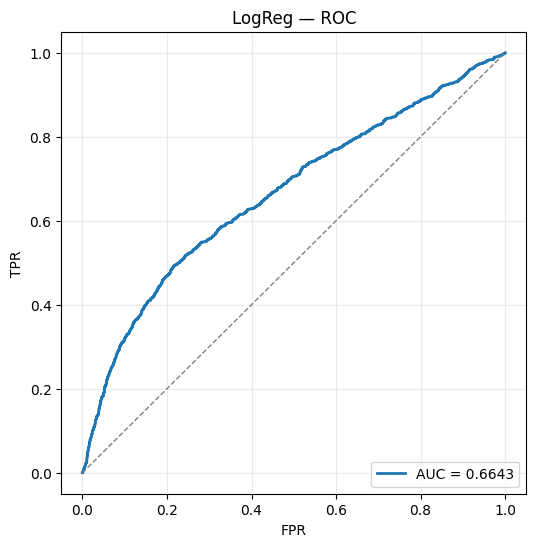

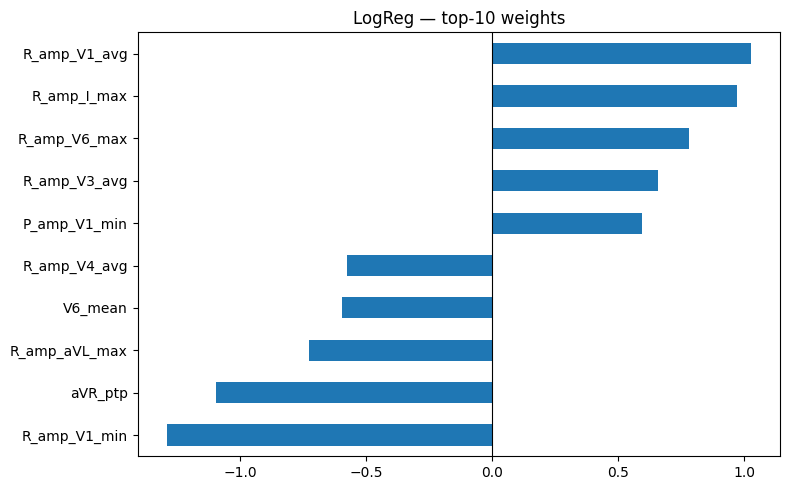

In [ ]:
probs_logreg_test = predict_logreg(logreg, scaler_lr, test_df, feature_cols)
probs_logreg_val  = predict_logreg(logreg, scaler_lr, val_df,  feature_cols)

metrics_logreg = compute_metrics(test_labels, probs_logreg_test)
print(json.dumps(metrics_logreg, indent=2))
save_metrics(metrics_logreg, MODELS / 'logreg_metrics.json')
plot_roc(test_labels, probs_logreg_test, title='LogReg — ROC',
         savepath=MODELS / 'logreg_roc.png')

coef = pd.Series(logreg.coef_.ravel(), index=feature_cols)
top10 = coef.abs().sort_values(ascending=False).head(10)
top10_sorted = coef.loc[top10.index].sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
top10_sorted.plot(kind='barh', ax=ax)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('LogReg — top-10 weights')
plt.tight_layout()
plt.savefig(MODELS / 'logreg_weights.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
from classic_ml import train_knn_optuna, predict_knn

knn, scaler_knn, study_knn = train_knn_optuna(
    train_df, val_df, feature_cols,
    n_trials=20,
    save_path=MODELS / 'knn.joblib',
)


  0%|          | 0/20 [00:00<?, ?it/s]

knn val AUC: 0.7540


{
  "roc_auc": 0.7654269782097216,
  "auc_pr": 0.26974534034963865,
  "top5_recall": 0.2639467110741049,
  "f1": 0.30719742661841576,
  "precision": 0.29704510108864696,
  "recall": 0.3180682764363031,
  "threshold": 0.43755673272176326,
  "n_pos": 1201,
  "n_neg": 16870
}


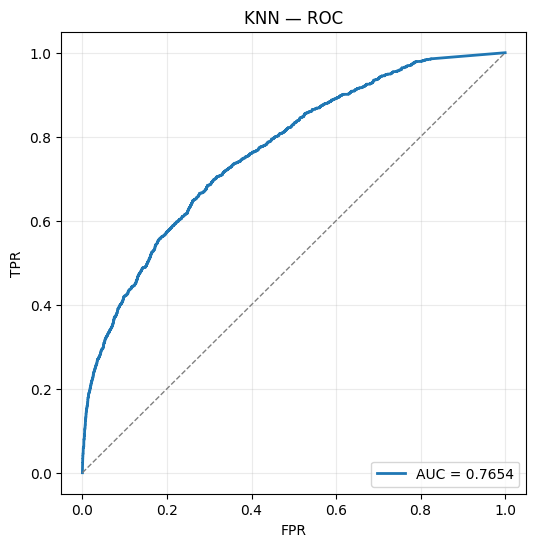

Best KNN params: {'n_neighbors': 41, 'weights': 'distance', 'metric': 'manhattan'}


In [ ]:
probs_knn_test = predict_knn(knn, scaler_knn, test_df, feature_cols)
probs_knn_val  = predict_knn(knn, scaler_knn, val_df,  feature_cols)

metrics_knn = compute_metrics(test_labels, probs_knn_test)
print(json.dumps(metrics_knn, indent=2))
save_metrics(metrics_knn, MODELS / 'knn_metrics.json')
plot_roc(test_labels, probs_knn_test, title='KNN — ROC',
         savepath=MODELS / 'knn_roc.png')

print('Best KNN params:', study_knn.best_params)


In [ ]:
from classic_ml import train_lgbm_optuna, predict_lgbm

lgbm, study_lgbm = train_lgbm_optuna(
    train_df, val_df, feature_cols,
    n_trials=15, random_state=42,
    save_path=MODELS / 'lgbm.joblib',
)


  0%|          | 0/15 [00:00<?, ?it/s]

lgbm val AUC: 0.8418


{
  "roc_auc": 0.8321947181932464,
  "auc_pr": 0.31899139713215247,
  "top5_recall": 0.2997502081598668,
  "f1": 0.3628058727569331,
  "precision": 0.2982832618025751,
  "recall": 0.462947543713572,
  "threshold": 0.3097106406062406,
  "n_pos": 1201,
  "n_neg": 16870
}


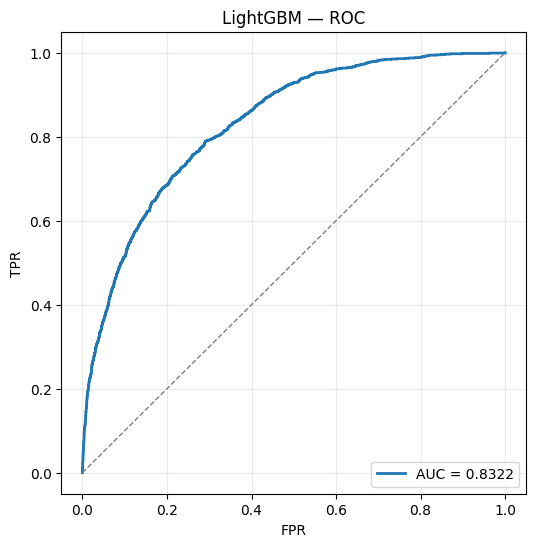

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'LightGBM — ROC'}, xlabel='FPR', ylabel='TPR'>)

In [ ]:
probs_lgbm_test = predict_lgbm(lgbm, test_df, feature_cols)
probs_lgbm_val  = predict_lgbm(lgbm, val_df,  feature_cols)

metrics_lgbm = compute_metrics(test_labels, probs_lgbm_test)
print(json.dumps(metrics_lgbm, indent=2))
save_metrics(metrics_lgbm, MODELS / 'lgbm_metrics.json')
plot_roc(test_labels, probs_lgbm_test, title='LightGBM — ROC',
         savepath=MODELS / 'lgbm_roc.png')


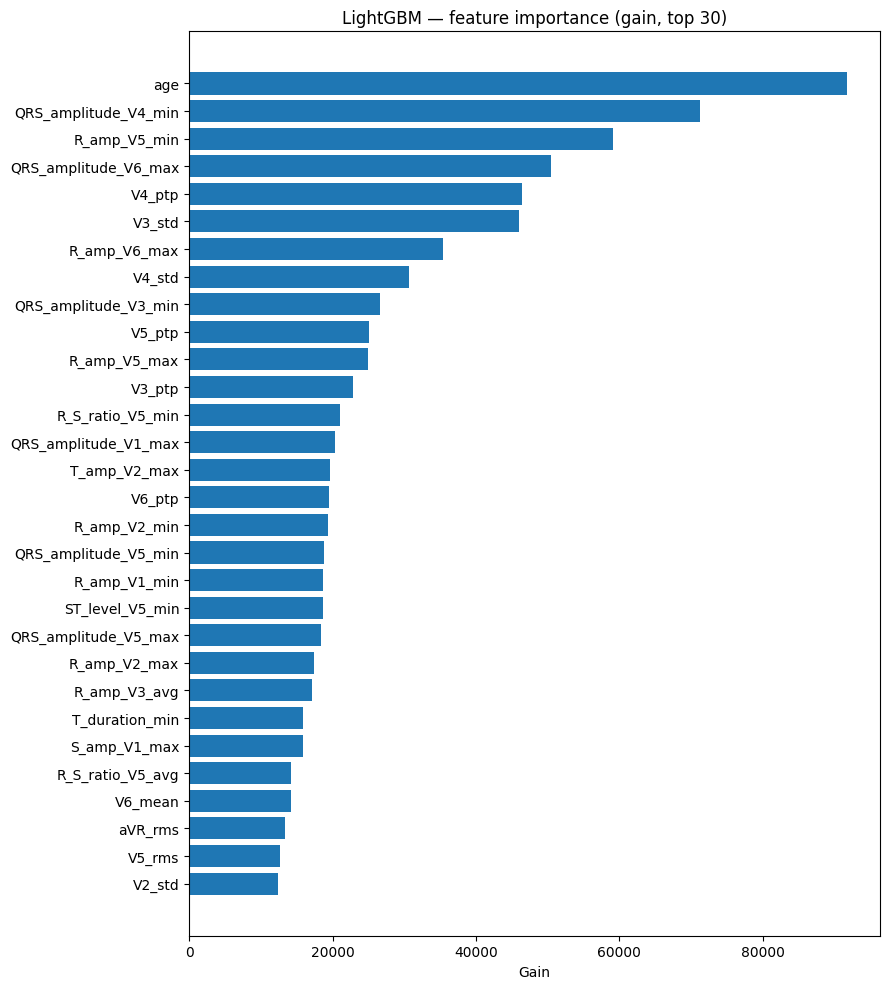

In [ ]:
gain  = lgbm.booster_.feature_importance(importance_type='gain')
fi_df = pd.DataFrame({'feature': feature_cols, 'gain': gain})
fi_df = fi_df.sort_values('gain', ascending=False).reset_index(drop=True)

plot_df = fi_df.head(30).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 10))
ax.barh(plot_df['feature'], plot_df['gain'])
ax.set_title('LightGBM — feature importance (gain, top 30)')
ax.set_xlabel('Gain')
plt.tight_layout()
plt.savefig(MODELS / 'lgbm_fi_gain.png', dpi=150, bbox_inches='tight')
plt.show()
fi_df.to_csv(MODELS / 'lgbm_fi_gain.csv', index=False)


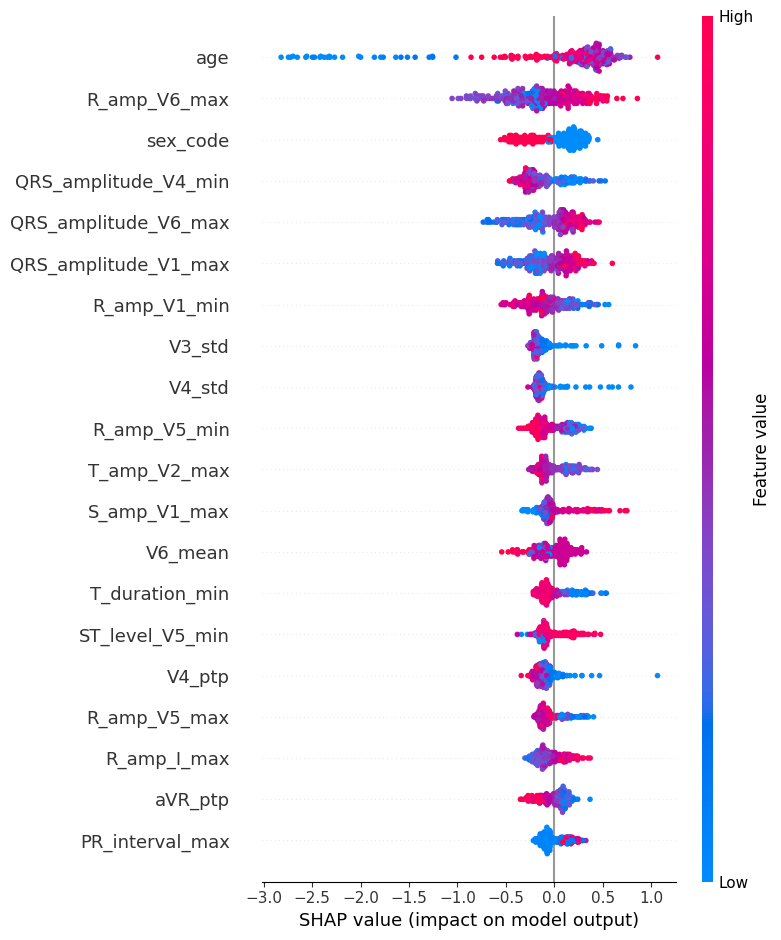

In [ ]:
import shap

rng        = np.random.RandomState(0)
pos_idx    = test_df.index[test_df['chagas_label'] == 1].to_numpy()
neg_idx    = test_df.index[test_df['chagas_label'] == 0].to_numpy()
shap_idx   = np.concatenate([
    rng.choice(pos_idx, size=min(150, len(pos_idx)), replace=False),
    rng.choice(neg_idx, size=min(150, len(neg_idx)), replace=False),
])
X_shap = test_df.loc[shap_idx, feature_cols].fillna(0.0).to_numpy(dtype=np.float32)

explainer   = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_shap)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap.summary_plot(shap_values, X_shap, feature_names=feature_cols,
                  max_display=20, show=False)
plt.tight_layout()
plt.savefig(MODELS / 'lgbm_shap.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
rows = []
for name, metrics in [
    ('LogReg',    metrics_logreg),
    ('KNN',       metrics_knn),
    ('LightGBM',  metrics_lgbm),
]:
    rows.append({
        'model':       name,
        'ROC-AUC':     metrics['roc_auc'],
        'AUC-PR':      metrics['auc_pr'],
        'top5_recall': metrics['top5_recall'],
        'F1':          metrics['f1'],
        'precision':   metrics['precision'],
        'recall':      metrics['recall'],
    })

compare = pd.DataFrame(rows).set_index('model')
print(compare.round(4).to_string())
compare.to_csv(MODELS / 'classic_ml_comparison.csv')


          ROC-AUC  AUC-PR  top5_recall      F1  precision  recall
model                                                            
LogReg     0.6643  0.1391       0.1624  0.2374     0.1927  0.3089
KNN        0.7654  0.2697       0.2639  0.3072     0.2970  0.3181
LightGBM   0.8322  0.3190       0.2998  0.3628     0.2983  0.4629


In [ ]:
record_col = 'record_name' if 'record_name' in val_df.columns else None

def _make_pred_df(df, label_arr, **prob_cols):
    d = {}
    if record_col:
        d['record_name'] = df[record_col].values
    d['chagas_label'] = label_arr
    d.update(prob_cols)
    return pd.DataFrame(d)

val_preds = _make_pred_df(
    val_df, val_labels,
    logreg_prob = probs_logreg_val,
    knn_prob    = probs_knn_val,
    lgbm_prob   = probs_lgbm_val,
)
val_preds.to_csv(MODELS / 'val_predictions.csv', index=False)

test_preds = _make_pred_df(
    test_df, test_labels,
    logreg_prob = probs_logreg_test,
    knn_prob    = probs_knn_test,
    lgbm_prob   = probs_lgbm_test,
)
test_preds.to_csv(MODELS / 'test_predictions.csv', index=False)

print('val_predictions.csv  →', MODELS / 'val_predictions.csv')
print('test_predictions.csv →', MODELS / 'test_predictions.csv')


val_predictions.csv  → /content/drive/MyDrive/Diplom2/checkpoints/classic/val_predictions.csv
test_predictions.csv → /content/drive/MyDrive/Diplom2/checkpoints/classic/test_predictions.csv
